In [3]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.metrics.cluster import (
    normalized_mutual_info_score,
    adjusted_rand_score
)
from scipy.stats import (
    kruskal,
    f_oneway
)
import matplotlib.pyplot as plt
import seaborn as sns

print("Loading evaluation datasets...")

notes = pd.read_csv(
    "../outputs/clustered_patients.csv"
)

W = np.load(
    "../features/W_nmf.npy"
)

topic_terms = pd.read_csv(
    "../outputs/topic_terms.csv"
)

diagnoses = pd.read_csv(
    "../datasets/DIAGNOSES_ICD_sorted.csv",
    usecols=[
        "HADM_ID",
        "ICD9_CODE",
        "SEQ_NUM"
    ]
)

print("\nLoaded successfully.")


Loading evaluation datasets...

Loaded successfully.


In [4]:
print("\n=== BASIC VALIDATION ===\n")
print("Patients:", len(notes))
print("W shape:", W.shape)
print(
    "Unique KMeans clusters:",
    notes["kmeans_cluster"].nunique()
)
print(
    "Unique Agglomerative clusters:",
    notes["agg_cluster"].nunique()
)


=== BASIC VALIDATION ===

Patients: 10710
W shape: (10710, 15)
Unique KMeans clusters: 7
Unique Agglomerative clusters: 7


In [5]:
print("\n=== CLUSTERING METRICS ===\n")
labels = notes["kmeans_cluster"]
sil = silhouette_score(
    W,
    labels,
    sample_size=min(5000, len(W))
)
dbi = davies_bouldin_score(
    W,
    labels
)
chi = calinski_harabasz_score(
    W,
    labels
)
print(f"Silhouette Score:       {sil:.4f}")
print(f"Davies-Bouldin Index:  {dbi:.4f}")
print(f"Calinski-Harabasz:     {chi:.4f}")


=== CLUSTERING METRICS ===

Silhouette Score:       0.3594
Davies-Bouldin Index:  1.0157
Calinski-Harabasz:     1786.4436


In [6]:
print("\n=== ICD ALIGNMENT ===\n")
primary_diag = diagnoses[
    diagnoses["SEQ_NUM"] == 1
].copy()
eval_df = notes.merge(
    primary_diag[
        ["HADM_ID", "ICD9_CODE"]
    ],
    on="HADM_ID",
    how="inner"
)
print("Evaluation rows:", len(eval_df))
icd_codes = (
    eval_df["ICD9_CODE"]
    .astype("category")
    .cat.codes
)
cluster_labels = (
    eval_df["kmeans_cluster"]
)
nmi = normalized_mutual_info_score(
    icd_codes,
    cluster_labels
)
ari = adjusted_rand_score(
    icd_codes,
    cluster_labels
)
print(f"NMI vs ICD-9: {nmi:.4f}")
print(f"ARI vs ICD-9: {ari:.4f}")


=== ICD ALIGNMENT ===

Evaluation rows: 10686
NMI vs ICD-9: 0.0649
ARI vs ICD-9: 0.0002



=== CLUSTER SIZES ===

kmeans_cluster
0    7343
1    1699
2     325
3     480
4      97
5     391
6     375
Name: count, dtype: int64


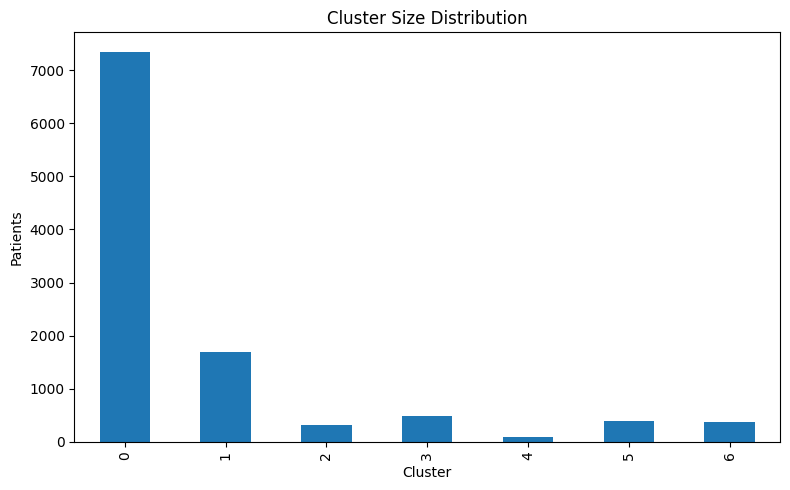

In [8]:
cluster_sizes = (
    notes["kmeans_cluster"]
    .value_counts()
    .sort_index()
)
print("\n=== CLUSTER SIZES ===\n")
print(cluster_sizes)
plt.figure(figsize=(8, 5))
cluster_sizes.plot(kind="bar")
plt.xlabel("Cluster")
plt.ylabel("Patients")
plt.title("Cluster Size Distribution")
plt.tight_layout()
plt.savefig(
    "../outputs/cluster_size_distribution.png",
    dpi=150
)
plt.show()

In [9]:
print("\n=== COMPLEXITY ANALYSIS ===\n")
complexity_stats = (
    notes.groupby("kmeans_cluster")
    ["complexity_score"]
    .describe()
)
print(complexity_stats)
cluster_complexities = [
    notes[
        notes["kmeans_cluster"] == c
    ]["complexity_score"]
    for c in sorted(
        notes["kmeans_cluster"].unique()
    )
]
kw_stat, kw_p = kruskal(
    *cluster_complexities
)
print(
    f"\nKruskal-Wallis p-value: "
    f"{kw_p:.6f}"
)


=== COMPLEXITY ANALYSIS ===

                 count      mean       std  min  25%  50%  75%  max
kmeans_cluster                                                     
0               7343.0  1.161923  0.834792  0.0  1.0  1.0  2.0  6.0
1               1699.0  2.426722  0.851669  1.0  2.0  2.0  3.0  6.0
2                325.0  1.526154  0.659750  1.0  1.0  1.0  2.0  4.0
3                480.0  1.554167  0.610608  1.0  1.0  1.0  2.0  3.0
4                 97.0  2.195876  0.772431  1.0  2.0  2.0  3.0  4.0
5                391.0  1.890026  0.813777  1.0  1.0  2.0  2.0  5.0
6                375.0  1.733333  0.692460  1.0  1.0  2.0  2.0  4.0

Kruskal-Wallis p-value: 0.000000


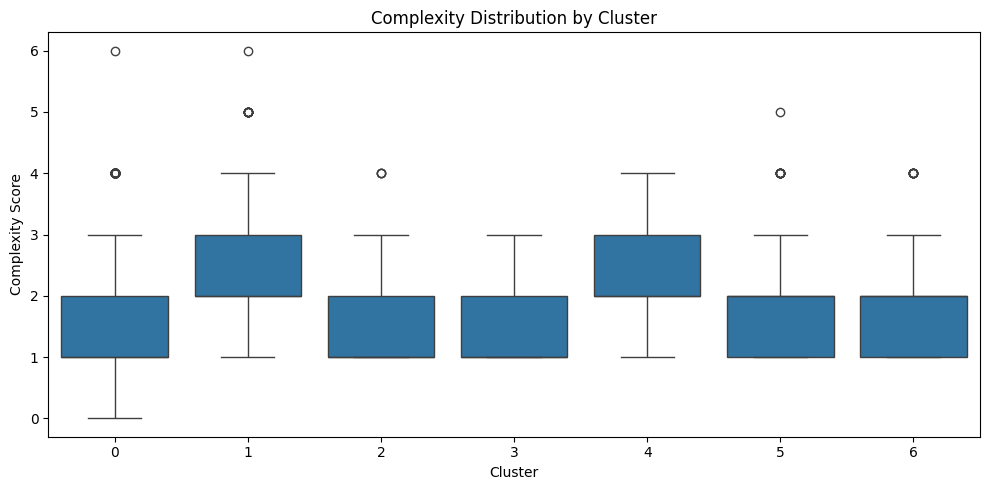

In [11]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=notes,
    x="kmeans_cluster",
    y="complexity_score"
)
plt.xlabel("Cluster")
plt.ylabel("Complexity Score")
plt.title("Complexity Distribution by Cluster")

plt.tight_layout()

plt.savefig(
    "../outputs/evaluation_complexity.png",
    dpi=150
)

plt.show()


=== MORTALITY ANALYSIS ===

kmeans_cluster
0    0.112399
1    0.102065
2    0.083077
3    0.088235
4    0.072165
5    0.121134
6    0.096257
Name: HOSPITAL_EXPIRE_FLAG, dtype: float64


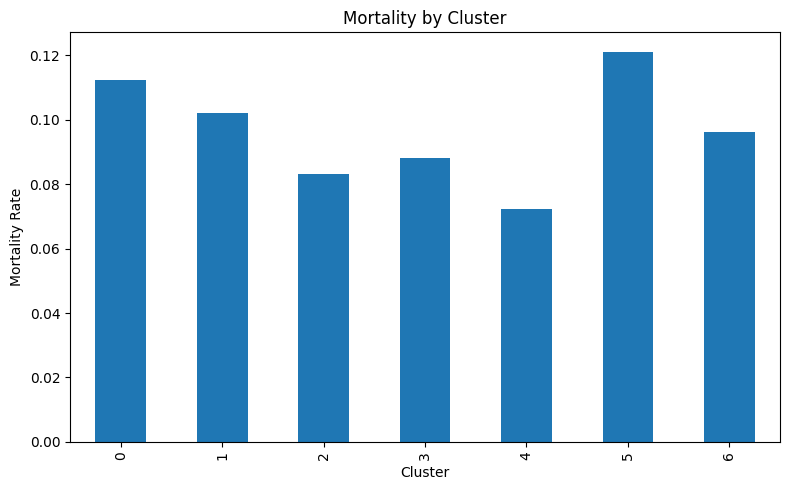

In [12]:
print("\n=== MORTALITY ANALYSIS ===\n")
mortality = (
    notes.groupby("kmeans_cluster")
    ["HOSPITAL_EXPIRE_FLAG"]
    .mean()
)
print(mortality)
plt.figure(figsize=(8, 5))

mortality.plot(kind="bar")

plt.xlabel("Cluster")
plt.ylabel("Mortality Rate")
plt.title("Mortality by Cluster")

plt.tight_layout()

plt.savefig(
    "../outputs/evaluation_mortality.png",
    dpi=150
)

plt.show()


In [13]:
print("\n=== DOMINANT TOPICS ===\n")
dominant_topic_counts = (
    notes["dominant_topic"]
    .value_counts()
    .sort_index()
)
print(dominant_topic_counts)



=== DOMINANT TOPICS ===

dominant_topic
0.0      372
1.0      183
2.0     1041
3.0      124
4.0      445
5.0      564
6.0      445
7.0     2024
8.0      423
9.0     1023
10.0     824
11.0     319
12.0     950
13.0    1571
14.0     402
Name: count, dtype: int64


In [14]:
print("\n=== TOPIC DISTINCTIVENESS ===\n")
topic_groups = topic_terms.groupby("topic")
topic_term_sets = {}
for topic, group in topic_groups:
    topic_term_sets[topic] = set(
        group.sort_values(
            "weight",
            ascending=False
        )
        .head(10)["term"]
    )
overlaps = []
topics = sorted(topic_term_sets.keys())
for i in range(len(topics)):
    for j in range(i + 1, len(topics)):
        overlap = len(
            topic_term_sets[topics[i]]
            &
            topic_term_sets[topics[j]]
        )
        overlaps.append(overlap)
avg_overlap = np.mean(overlaps)
print(
    f"Average top-term overlap: "
    f"{avg_overlap:.2f}"
)


=== TOPIC DISTINCTIVENESS ===

Average top-term overlap: 0.22


In [15]:
print("\n=== TOPIC ENTROPY ===\n")
topic_cols = [
    col for col in notes.columns
    if col.startswith("topic_")
]
if len(topic_cols) > 0:
    entropies = []
    for _, row in notes[topic_cols].iterrows():
        probs = row.values
        probs = probs / (
            probs.sum() + 1e-10
        )
        entropy = -np.sum(
            probs * np.log(probs + 1e-10)
        )
        entropies.append(entropy)
    notes["topic_entropy"] = entropies
    entropy_stats = (
        notes.groupby("kmeans_cluster")
        ["topic_entropy"]
        .mean()
    )
    print(entropy_stats)


=== TOPIC ENTROPY ===

kmeans_cluster
0    2.014903e-09
1    6.021274e-10
2    3.101869e-10
3    3.379134e-10
4    1.766619e-10
5    3.603279e-10
6    3.270681e-10
Name: topic_entropy, dtype: float64


In [16]:

print("\n=== TOP ICD-9 DIAGNOSES PER CLUSTER ===\n")
cluster_diag = eval_df.groupby(
    ["kmeans_cluster", "ICD9_CODE"]
).size().reset_index(name="count")
for cluster_id in sorted(
    eval_df["kmeans_cluster"].unique()
):
    print("\n" + "=" * 80)
    print(f"CLUSTER {cluster_id}")
    top_diag = (
        cluster_diag[
            cluster_diag["kmeans_cluster"]
            == cluster_id
        ]
        .sort_values(
            "count",
            ascending=False
        )
        .head(10)
    )
    print(top_diag)



=== TOP ICD-9 DIAGNOSES PER CLUSTER ===


CLUSTER 0
      kmeans_cluster ICD9_CODE  count
338                0     41401    513
1140               0     V3001    309
20                 0      0389    270
331                0     41071    267
1139               0     V3000    229
1143               0     V3101    196
513                0     51881    165
356                0      4241    128
388                0       431    109
496                0      5070    104

CLUSTER 1
      kmeans_cluster ICD9_CODE  count
1306               1     41401    112
1642               1     V3001     98
1170               1      0389     66
1302               1     41071     58
1644               1     V3101     52
1641               1     V3000     49
1390               1     51881     40
1295               1     41011     31
1336               1       431     30
1327               1      4280     29

CLUSTER 2
      kmeans_cluster ICD9_CODE  count
1695               2     41401     19
1829         

In [17]:
summary_table = pd.DataFrame({
    "Metric": [
        "Silhouette Score",
        "Davies-Bouldin Index",
        "Calinski-Harabasz Score",
        "NMI vs ICD-9",
        "ARI vs ICD-9",
        "Average Topic Overlap",
        "Number of Clusters",
        "Number of Topics",
        "Patients"

    ],
    "Value": [
        sil,
        dbi,
        chi,
        nmi,
        ari,
        avg_overlap,
        notes["kmeans_cluster"].nunique(),
        W.shape[1],
        len(notes)
    ]
})
print("\n=== FINAL EVALUATION TABLE ===\n")
print(summary_table)


=== FINAL EVALUATION TABLE ===

                    Metric         Value
0         Silhouette Score      0.359441
1     Davies-Bouldin Index      1.015692
2  Calinski-Harabasz Score   1786.443599
3             NMI vs ICD-9      0.064904
4             ARI vs ICD-9      0.000230
5    Average Topic Overlap      0.219048
6       Number of Clusters      7.000000
7         Number of Topics     15.000000
8                 Patients  10710.000000


In [18]:
summary_table.to_csv(
    "../outputs/evaluation_summary.csv",
    index=False
)
print("\nSaved evaluation summary.")

notes.to_csv(
    "../outputs/evaluated_patients.csv",
    index=False
)
print("\nSaved evaluated dataset.")


Saved evaluation summary.

Saved evaluated dataset.


In [19]:
print("\n=== INTERPRETATION ===\n")
if nmi < 0.3:
    print(
        "Low NMI suggests symptom clusters "
        "do not align strongly with ICD diagnoses."
    )
    print(
        "This supports the hypothesis that "
        "latent symptom complexity reveals "
        "hidden patient phenotypes."
    )
else:
    print(
        "Clusters strongly align with ICD diagnoses."
    )
if sil > 0.2:
    print(
        "\nClusters show meaningful separation."
    )
else:
    print(
        "\nClusters overlap substantially."
    )


=== INTERPRETATION ===

Low NMI suggests symptom clusters do not align strongly with ICD diagnoses.
This supports the hypothesis that latent symptom complexity reveals hidden patient phenotypes.

Clusters show meaningful separation.


In [20]:
print("\n=== FINAL SUMMARY ===\n")
print(f"Patients evaluated: {len(notes):,}")
print(
    f"Clusters: "
    f"{notes['kmeans_cluster'].nunique()}"
)
print(
    f"NMF topics: "
    f"{W.shape[1]}"
)

print(
    f"NMI vs ICD-9: "
    f"{nmi:.4f}"
)
print(
    f"Silhouette score: "
    f"{sil:.4f}"
)
print("\nEvaluation complete.")


=== FINAL SUMMARY ===

Patients evaluated: 10,710
Clusters: 7
NMF topics: 15
NMI vs ICD-9: 0.0649
Silhouette score: 0.3594

Evaluation complete.
